In [1]:
# what featrures does this have

import h5py

file = h5py.File('/Users/wen/Desktop/project/archive/5x64x64_training_with_morphology.hdf5','r')

print(list(file.keys()))

['coord', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad', 'i_pos_angle', 'i_sersic_index', 'image', 'object_id', 'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad', 'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma', 'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area', 'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness', 'r_petro_rad', 'r_pos_angle', 'r_sersic_index', 'ra', 'skymap_id', 'specz_dec', 'specz_flag_homogeneous', 

In [2]:
for key in file.keys():
    print(key, file[key].shape)

coord (204573,)
dec (204573,)
g_central_image_pop_10px_rad (204573,)
g_central_image_pop_15px_rad (204573,)
g_central_image_pop_5px_rad (204573,)
g_cmodel_mag (204573,)
g_cmodel_magsigma (204573,)
g_ellipticity (204573,)
g_half_light_radius (204573,)
g_isophotal_area (204573,)
g_major_axis (204573,)
g_minor_axis (204573,)
g_peak_surface_brightness (204573,)
g_petro_rad (204573,)
g_pos_angle (204573,)
g_sersic_index (204573,)
i_central_image_pop_10px_rad (204573,)
i_central_image_pop_15px_rad (204573,)
i_central_image_pop_5px_rad (204573,)
i_cmodel_mag (204573,)
i_cmodel_magsigma (204573,)
i_ellipticity (204573,)
i_half_light_radius (204573,)
i_isophotal_area (204573,)
i_major_axis (204573,)
i_minor_axis (204573,)
i_peak_surface_brightness (204573,)
i_petro_rad (204573,)
i_pos_angle (204573,)
i_sersic_index (204573,)
image (204573, 5, 64, 64)
object_id (204573,)
r_central_image_pop_10px_rad (204573,)
r_central_image_pop_15px_rad (204573,)
r_central_image_pop_5px_rad (204573,)
r_cmodel_m

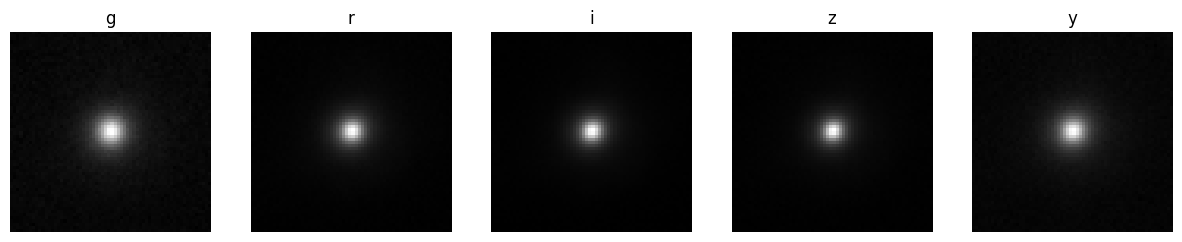

In [13]:
idx = 1024
img = file['image'][idx]

fig,axs = plt.subplots(1,5,figsize=(15,3))

bands = ['g','r','i','z','y']

for i in range(5):
    axs[i].imshow(img[i], cmap='gray')
    axs[i].set_title(bands[i])
    axs[i].axis('off')

plt.show()

# same galaxy, diff bands

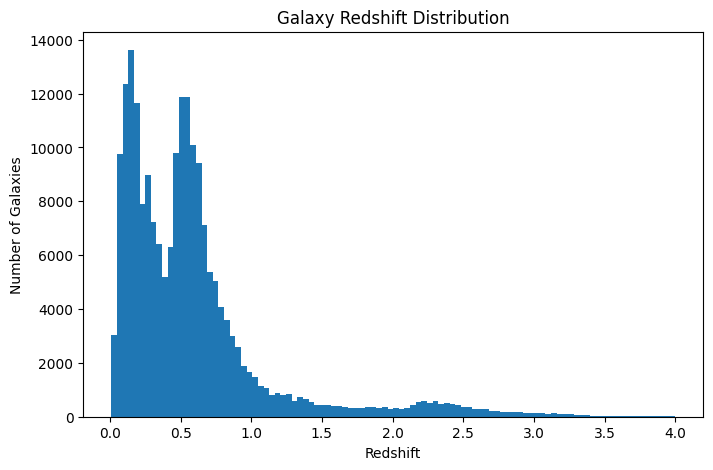

In [6]:
z = file['specz_redshift'][:]

plt.figure(figsize=(8,5))
plt.hist(z, bins=100)
plt.xlabel("Redshift")
plt.ylabel("Number of Galaxies")
plt.title("Galaxy Redshift Distribution")
plt.show()

# z larger, older and further galaxies

z range 0-0.5 galaxies: 105195


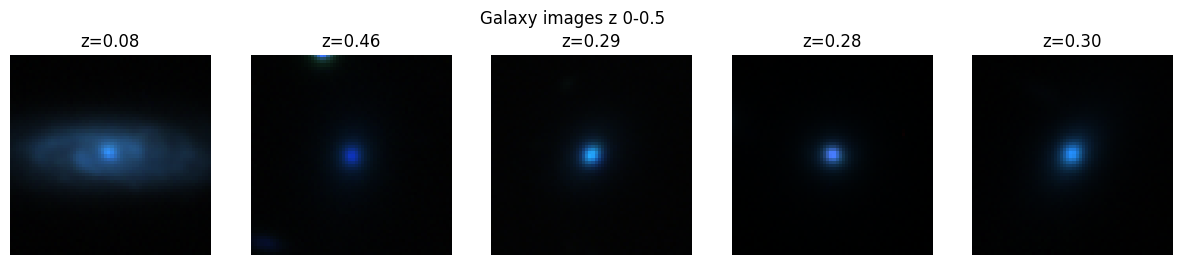

z range 0.5-1 galaxies: 74382


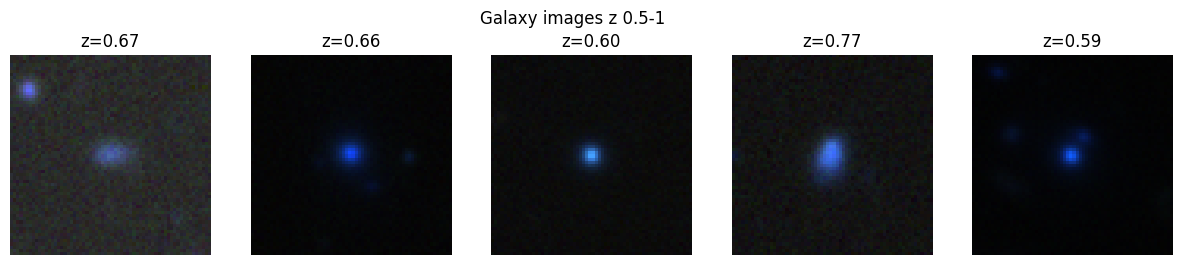

z range 1-2 galaxies: 14842


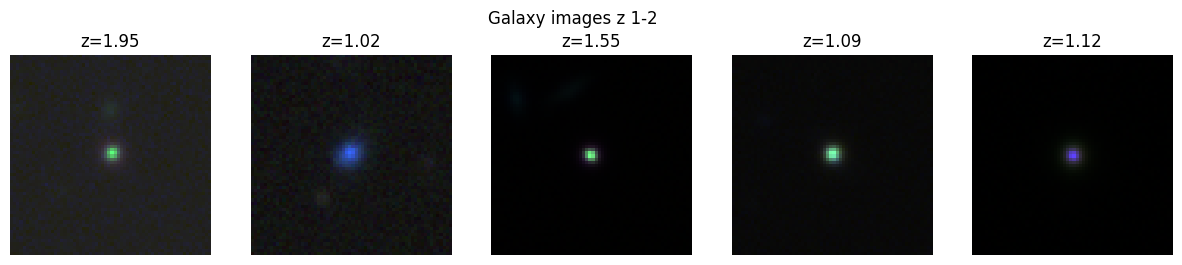

z range 2-3 galaxies: 8592


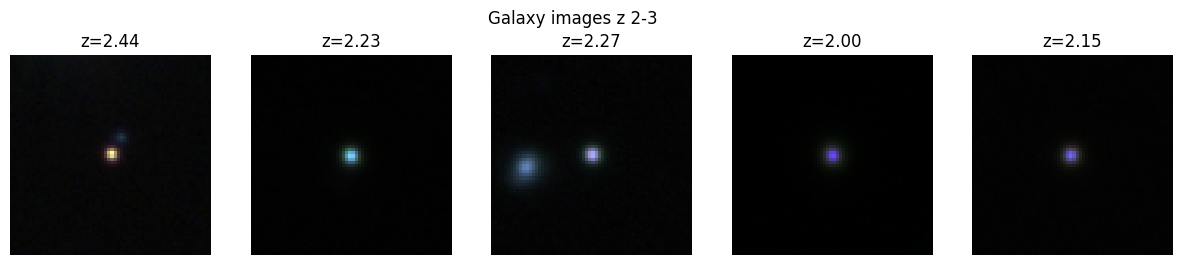

z range 3-4 galaxies: 1562


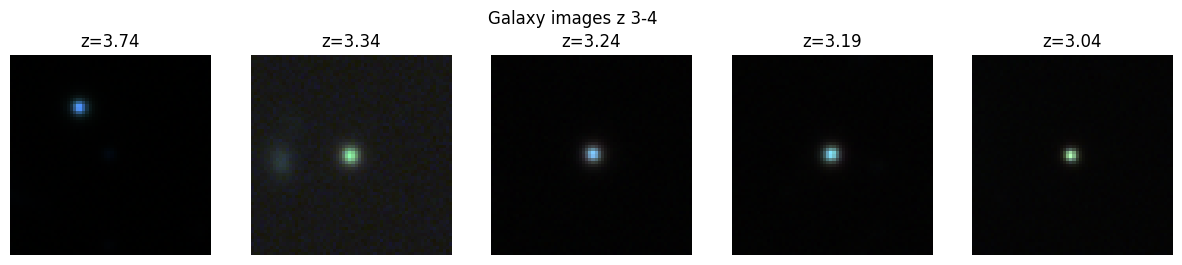

In [7]:
import numpy as np

images = file['image']
z = file['specz_redshift'][:]

bins = [(0,0.5),(0.5,1),(1,2),(2,3),(3,4)]

for zmin,zmax in bins:

    idx = np.where((z>=zmin)&(z<zmax))[0]

    print(f"z range {zmin}-{zmax} galaxies:",len(idx))

    sample = np.random.choice(idx,5)

    fig,axs = plt.subplots(1,5,figsize=(15,3))

    for i,id in enumerate(sample):

        img = images[id]

        # combine g r i into RGB
        rgb = np.stack([img[0],img[1],img[2]],axis=-1)

        rgb = (rgb-rgb.min())/(rgb.max()-rgb.min()+1e-5)

        axs[i].imshow(rgb)
        axs[i].axis("off")
        axs[i].set_title(f"z={z[id]:.2f}")

    plt.suptitle(f"Galaxy images z {zmin}-{zmax}")
    plt.show()

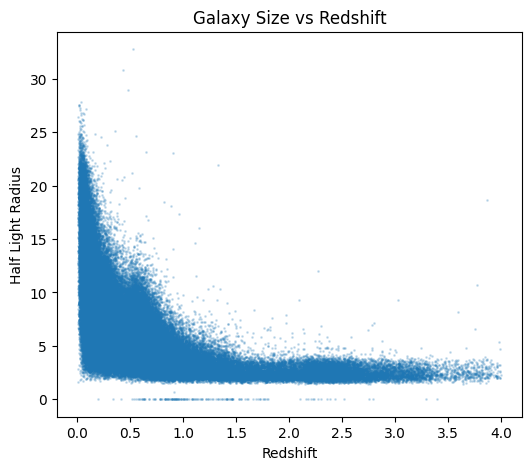

In [8]:
r = file['r_half_light_radius'][:]

plt.figure(figsize=(6,5))
plt.scatter(z,r,s=1,alpha=0.2)
plt.xlabel("Redshift")
plt.ylabel("Half Light Radius")
plt.title("Galaxy Size vs Redshift")
plt.show()